In [1]:
import pandas as pd
import numpy as np
import seaborn as sns;sns.set_style('white')
import matplotlib.pyplot as plt
#from sklearn.cluster import AgglomerativeClustering
#from sklearn.metrics.cluster import adjusted_rand_score
#from sklearn.metrics.cluster import normalized_mutual_info_score
#from scipy.cluster.hierarchy import fcluster,dendrogram,linkage
#from scipy.spatial.distance import squareform
import itertools
from matplotlib.pyplot import figure
from matplotlib.colors import LogNorm, Normalize
import warnings
from tqdm import tqdm
import random
warnings.simplefilter("ignore")

### Plot for Figure 2D

In [5]:
df_cluster_quality = pd.read_csv('./rand_score_errorbars_new.csv',
                                index_col=None)

mod_dict = {'original':'original',
           'length':'only length filtering',
           'only_flanked': 'only flanked',
           'length_flanking': 'length filtering + flanking',
           'uniq_length': 'unique sequences + length filtering',
           'clonal_pat': 'clonal filtering within a donor',
           'clonal_all_df': 'single linkage clustering across donors'}

#mod_dict = {'original':'обычный',
#           'length':'фильтрация по длине',
#           'only_flanked': 'фланкирование',
#           'length_flanking': 'фильтрация по длине + фланкирование',
#           'uniq_length': 'уникальные последовательности + фильтрация по длине',
#           'clonal_pat': 'фильтрация клонов в рамках одного пациента',
#           'clonal_all_df': 'фильтрация клонов во всем датасете'}

df_cluster_quality['modification'] = df_cluster_quality['modification'].apply(lambda x: mod_dict[x])
embedding_dict = {'ESM2': r"ESM2 — $W_2$",
                 'OHE': r'OHE — $W_2$',
                 'AB2': r'AB2 — $W_2$',
                 'SONIA': 'LeftRight — Pearson',
                 'Jaccard': 'Jaccard'}

df_cluster_quality['embedding'] = df_cluster_quality['embedding'].apply(lambda x: embedding_dict[x])

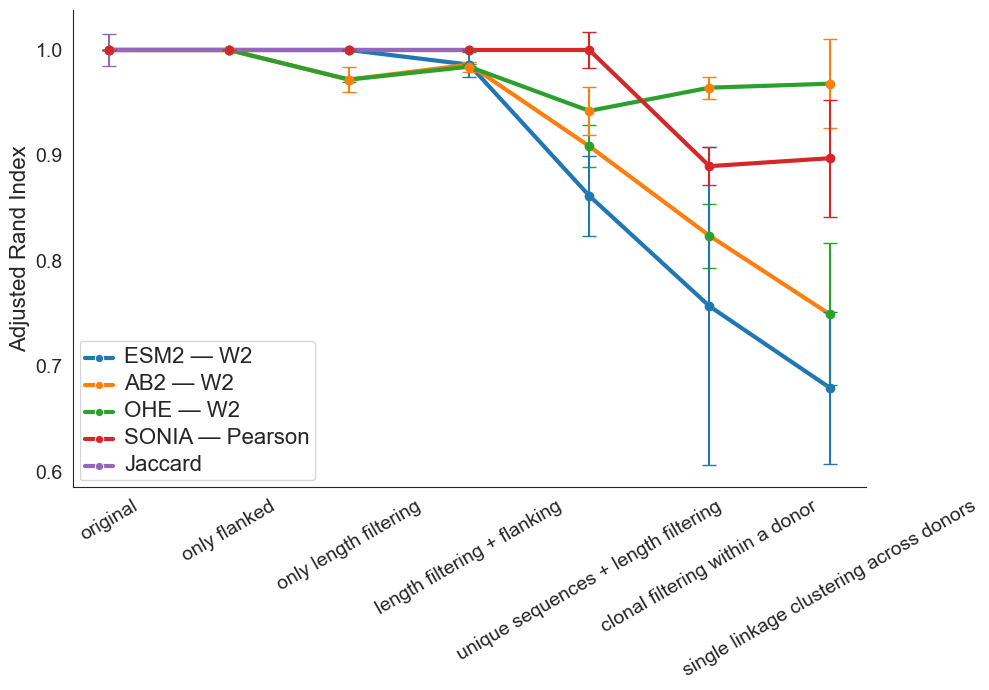

In [4]:
plt.rcParams["figure.figsize"] = (10,7)


g = sns.lineplot(data=df_cluster_quality, x='modification', y='median', hue='embedding',
             linewidth=3,marker='o')
g.legend_.set_title(None)
plt.setp(g.legend_.get_texts(), fontsize=16)  # ← Set legend text size here

colors = [sns.color_palette()[2],
          sns.color_palette()[0],
          sns.color_palette()[4],
          sns.color_palette()[1],          
          sns.color_palette()[3]]


for color, (key, grp) in zip(colors,df_cluster_quality.groupby('embedding')):
    plt.errorbar(grp['modification'], grp['median'], 
                 yerr=[grp['std'],grp['std']], 
                 fmt='o', 
                 color = color,
                 capsize=5,  # size of the caps at the end of the error bars
                 label=key)
    
# Настройка графика
plt.xlabel('')
plt.ylabel('Adjusted Rand Index',fontsize=16)
#plt.ylim([0,1.1])
plt.xticks(fontsize=14,rotation=30)
plt.yticks(fontsize=14)
sns.despine()
# Показать график
plt.tight_layout()
plt.savefig('Rand_errorbars.png', dpi=300)

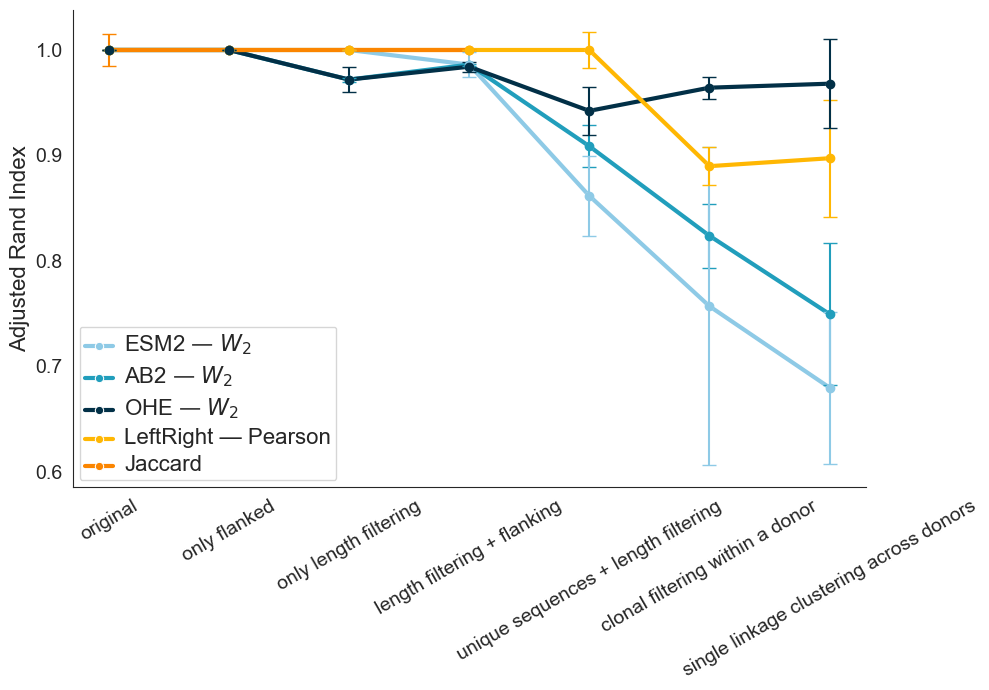

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 7)

# Define explicit color mapping
embedding_order = df_cluster_quality['embedding'].unique()
custom_color_dict = {
    embedding: color for embedding, color in zip(
        embedding_order,
        ['#8ECAE6', '#219EBC', '#023047', '#FFB703', '#FB8500']
    )
}

# Pass this mapping to Seaborn
g = sns.lineplot(
    data=df_cluster_quality,
    x='modification',
    y='median',
    hue='embedding',
    hue_order=embedding_order,
    linewidth=3,
    marker='o',
    palette=custom_color_dict
)

# Style legend
g.legend_.set_title(None)
plt.setp(g.legend_.get_texts(), fontsize=16)

# Overlay error bars with same color mapping
for key, grp in df_cluster_quality.groupby('embedding'):
    color = custom_color_dict[key]
    plt.errorbar(
        grp['modification'],
        grp['median'],
        yerr=[grp['std'], grp['std']],
        fmt='o',
        color=color,
        capsize=5,
        label=key
    )

# Final formatting
plt.xlabel('')
plt.ylabel('Adjusted Rand Index', fontsize=16)
plt.xticks(fontsize=14, rotation=30)
plt.yticks(fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig('Rand_errorbars.png', dpi=300)
